# 04 - Exploratory Data Analysis (EDA)

## Electricity Consumption Analysis and Short-Term Demand Forecasting

### Objective

Explore the cleaned hourly electricity-consumption dataset to understand its major patterns, trends, distributions, relationships, and peak-demand periods.

### Questions we want to answer

1. How does electricity consumption change over time?
2. Which hours have the highest average consumption?
3. Which days of the week have the highest consumption?
4. How does weekday consumption compare with weekend consumption?
5. How does consumption vary by month?
6. What are the peak and low-consumption periods?
7. How is electricity consumption distributed?
8. Are there relationships between electricity-related variables?
9. Are there unusually high or low consumption observations?

The findings from this notebook will guide the feature engineering and machine-learning stages.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Load the Hourly Dataset

The hourly dataset was created in `03_hourly_aggregation.ipynb`.


In [2]:
file_path = "../data/processed/hourly_electricity_consumption.csv"

hourly_df = pd.read_csv(
    file_path,
    parse_dates=["DateTime"]
)

hourly_df = hourly_df.set_index("DateTime").sort_index()

print("Dataset shape:", hourly_df.shape)
hourly_df.head()

Dataset shape: (24584, 15)


,Electricity_Consumption,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Year,Month,Day,Hour,DayOfWeek,IsWeekend,Quarter,DayName
DateTime,,,,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,2006,12,16,17,5,1,4,Saturday
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,2006,12,16,18,5,1,4,Saturday
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,2006,12,16,19,5,1,4,Saturday
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,2006,12,16,20,5,1,4,Saturday
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,2006,12,16,21,5,1,4,Saturday


## 3. Dataset Information


In [3]:
hourly_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 24584 entries, 2006-12-16 17:00:00 to 2009-10-06 00:00:00
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Electricity_Consumption  24584 non-null  float64
 1   Global_reactive_power    24584 non-null  float64
 2   Voltage                  24584 non-null  float64
 3   Global_intensity         24584 non-null  float64
 4   Sub_metering_1           24584 non-null  float64
 5   Sub_metering_2           24584 non-null  float64
 6   Sub_metering_3           24584 non-null  float64
 7   Year                     24584 non-null  int64  
 8   Month                    24584 non-null  int64  
 9   Day                      24584 non-null  int64  
 10  Hour                     24584 non-null  int64  
 11  DayOfWeek                24584 non-null  int64  
 12  IsWeekend                24584 non-null  int64  
 13  Quarter                  24584 non-null  int64  
 14

## 4. Descriptive Statistics

Start with a statistical summary of the main electricity-consumption variable.


In [4]:
hourly_df["Electricity_Consumption"].describe()

count    24584.000000
mean         1.083457
std          0.925465
min          0.124000
25%          0.323125
50%          0.761883
75%          1.574867
max          6.560533
Name: Electricity_Consumption, dtype: float64

## 5. Overall Electricity Consumption Trend

Visualize hourly electricity consumption across the complete period.

This graph helps us identify long-term changes, recurring fluctuations, and unusually high or low periods.


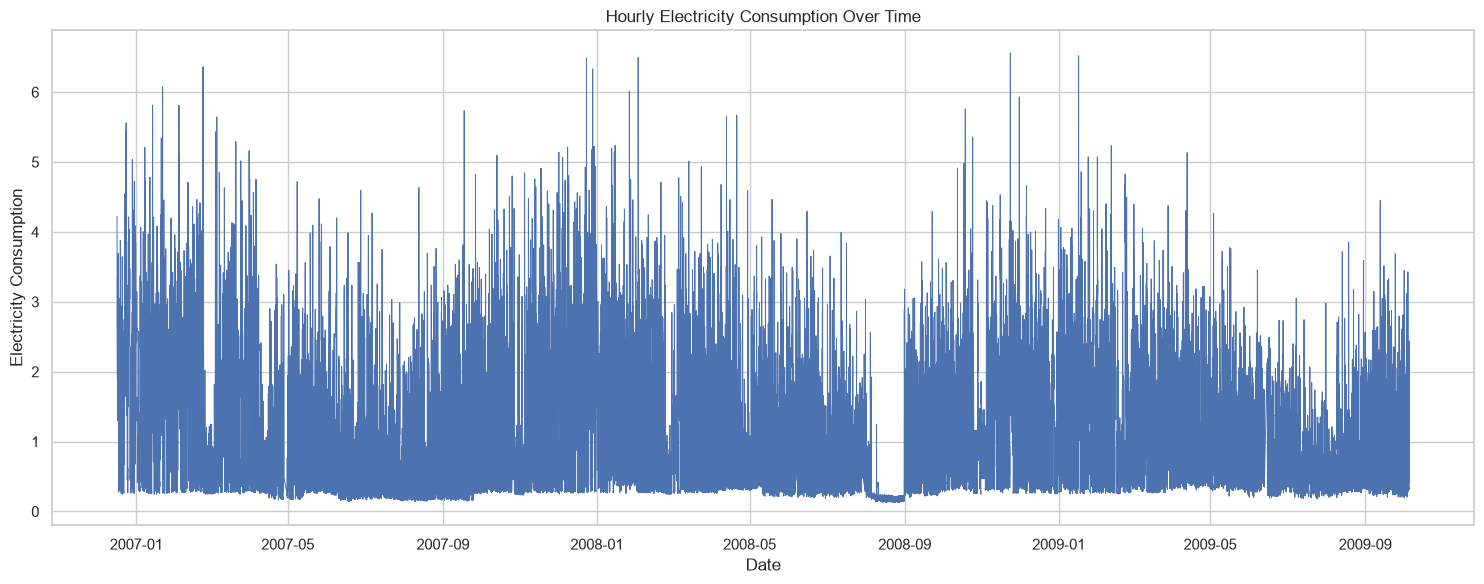

In [5]:
plt.figure(figsize=(15, 6))

plt.plot(
    hourly_df.index,
    hourly_df["Electricity_Consumption"],
    linewidth=0.7
)

plt.title("Hourly Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Electricity Consumption")
plt.tight_layout()
plt.show()

## 6. Distribution of Electricity Consumption

A histogram shows how frequently different consumption levels occur.

This helps us understand whether consumption is concentrated around a typical level or has a long tail caused by high-demand periods.


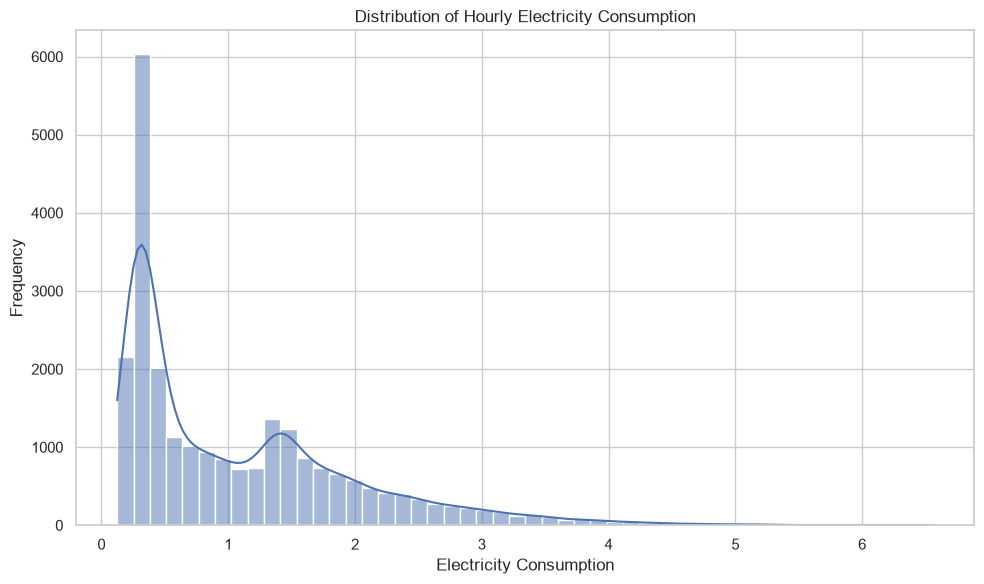

In [6]:
plt.figure(figsize=(10, 6))

sns.histplot(
    hourly_df["Electricity_Consumption"],
    bins=50,
    kde=True
)

plt.title("Distribution of Hourly Electricity Consumption")
plt.xlabel("Electricity Consumption")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 7. Boxplot of Electricity Consumption

A boxplot helps identify the median, spread, and potential extreme observations.


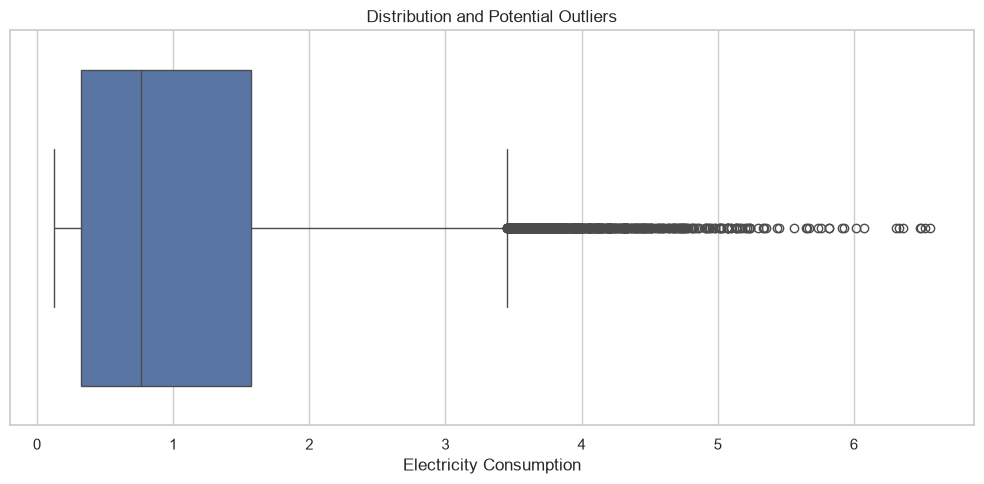

In [7]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=hourly_df["Electricity_Consumption"]
)

plt.title("Distribution and Potential Outliers")
plt.xlabel("Electricity Consumption")
plt.tight_layout()
plt.show()

## 8. Average Consumption by Hour

Electricity demand often follows a daily pattern.

Calculate the average consumption for each hour of the day.


In [8]:
hourly_pattern = (
    hourly_df.groupby("Hour")["Electricity_Consumption"]
    .mean()
)

hourly_pattern

Hour
0     0.662266
1     0.534260
2     0.469880
3     0.443495
4     0.446498
5     0.458132
6     0.810217
7     1.481431
8     1.457027
9     1.308342
10    1.232095
11    1.209848
12    1.169573
13    1.115923
14    1.060655
15    0.961619
16    0.924266
17    1.030173
18    1.304436
19    1.740989
20    1.911750
21    1.917081
22    1.435945
23    0.914860
Name: Electricity_Consumption, dtype: float64

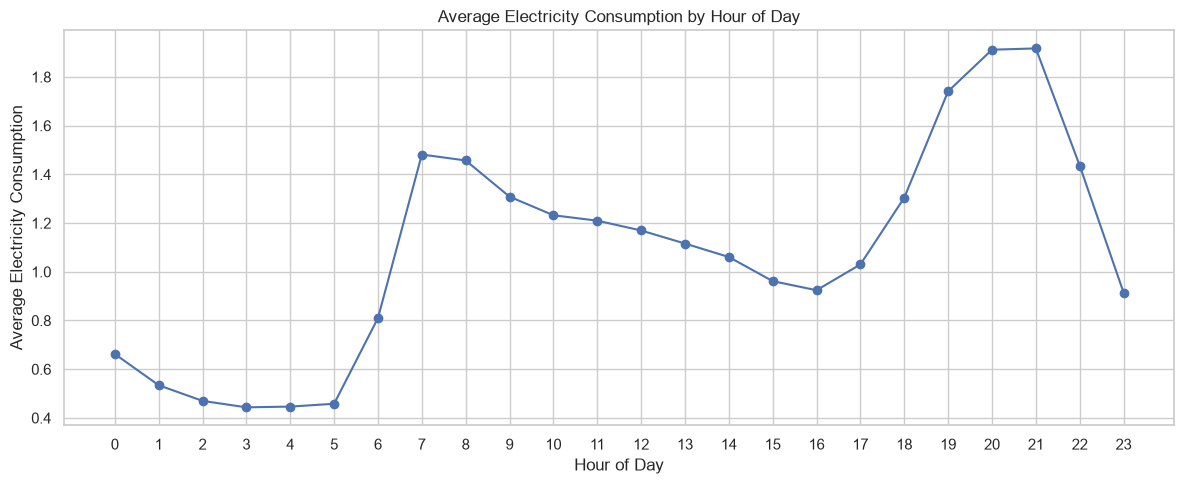

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.title("Average Electricity Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Electricity Consumption")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


### Interpretation

Use the graph to identify:

- the approximate peak-demand hours,
- the low-demand hours,
- whether consumption rises during morning or evening,
- whether the daily pattern appears consistent.


## 9. Average Consumption by Day of Week

Calculate the average consumption for each day of the week.


In [10]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_pattern = (
    hourly_df.groupby("DayName")["Electricity_Consumption"]
    .mean()
    .reindex(day_order)
)

day_pattern

DayName
Monday       0.979632
Tuesday      1.066451
Wednesday    1.061840
Thursday     0.945995
Friday       1.042660
Saturday     1.248035
Sunday       1.238904
Name: Electricity_Consumption, dtype: float64

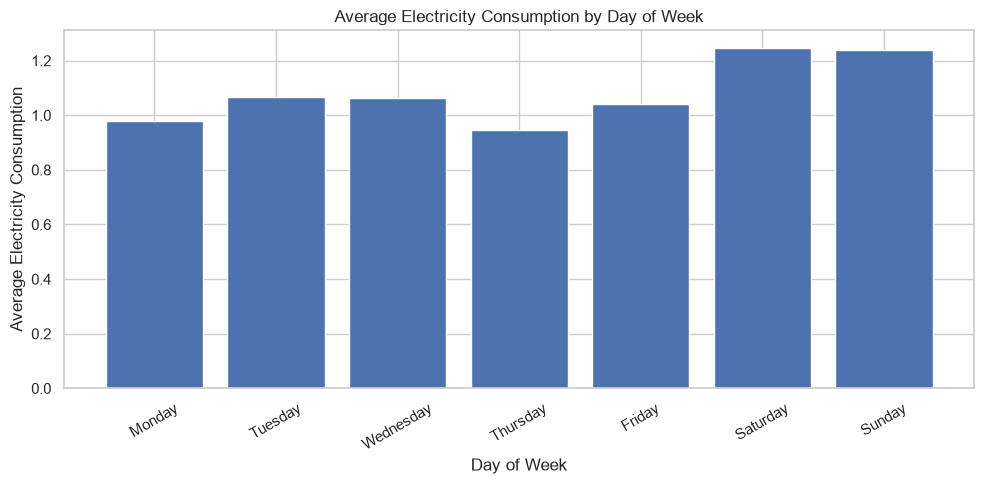

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_pattern.index,
    day_pattern.values
)

plt.title("Average Electricity Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Electricity Consumption")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 10. Weekday vs Weekend Consumption

Compare average electricity consumption between weekdays and weekends.


In [12]:
weekend_pattern = (
    hourly_df.groupby("IsWeekend")["Electricity_Consumption"]
    .mean()
)

weekend_pattern.index = ["Weekday", "Weekend"]

weekend_pattern

Weekday    1.019264
Weekend    1.243459
Name: Electricity_Consumption, dtype: float64

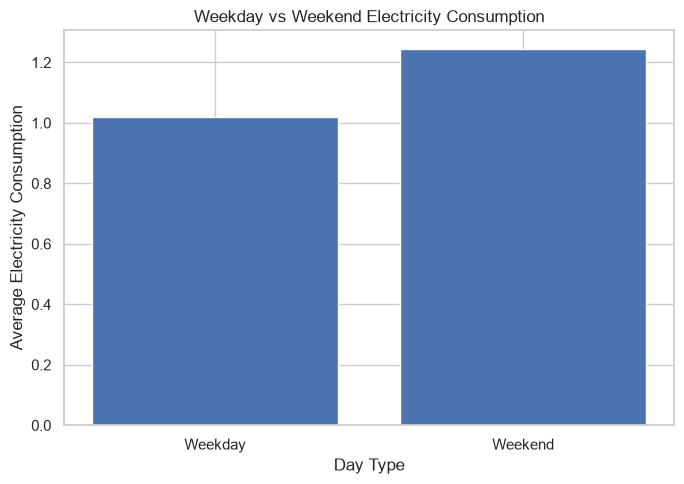

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    weekend_pattern.index,
    weekend_pattern.values
)

plt.title("Weekday vs Weekend Electricity Consumption")
plt.xlabel("Day Type")
plt.ylabel("Average Electricity Consumption")
plt.tight_layout()
plt.show()

## 11. Average Consumption by Month

Calculate the average electricity consumption for each month.


In [14]:
month_pattern = (
    hourly_df.groupby("Month")["Electricity_Consumption"]
    .mean()
)

month_pattern

Month
1     1.472121
2     1.275429
3     1.263607
4     1.034074
5     1.007663
6     0.897804
7     0.693767
8     0.565694
9     0.981352
10    1.109701
11    1.340962
12    1.540910
Name: Electricity_Consumption, dtype: float64

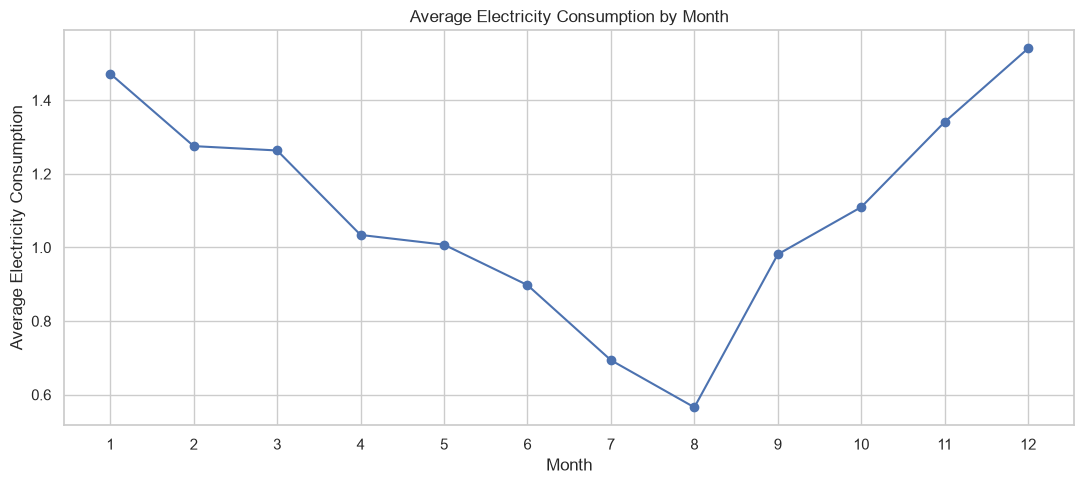

In [15]:
plt.figure(figsize=(11, 5))

plt.plot(
    month_pattern.index,
    month_pattern.values,
    marker="o"
)

plt.title("Average Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Electricity Consumption")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 12. Monthly Consumption Across Years

The same calendar month may behave differently in different years.

Create a year-by-month table to compare patterns across the dataset.


In [16]:
year_month = pd.pivot_table(
    hourly_df,
    values="Electricity_Consumption",
    index="Month",
    columns="Year",
    aggfunc="mean"
)

year_month

Year,2006,2007,2008,2009
Month,,,,
1,NaN,1.546086,1.459987,1.410289
2,NaN,1.401211,1.181467,1.246964
3,NaN,1.318609,1.245345,1.226865
4,NaN,0.845583,1.115972,1.140665
5,NaN,0.985862,1.024303,1.012824
6,NaN,0.827179,0.994090,0.872142
7,NaN,0.668344,0.794765,0.618191
8,NaN,0.764350,0.276530,0.656203
9,NaN,0.969487,0.987680,0.986889


## 13. Year-by-Month Heatmap

A heatmap makes it easier to compare average consumption across months and years.


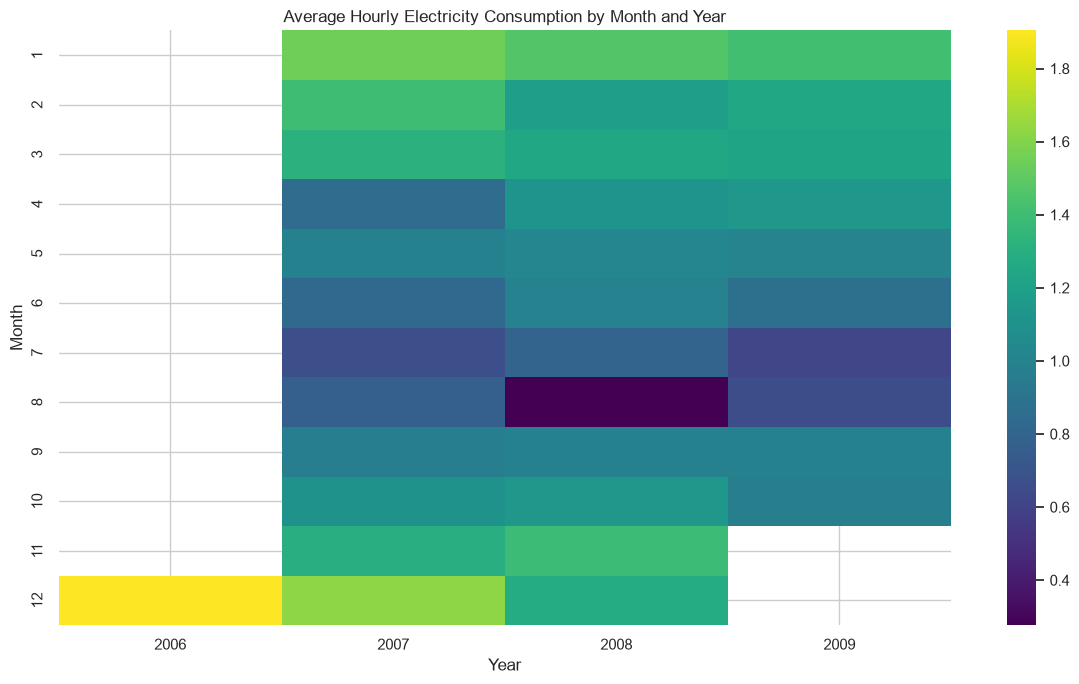

In [17]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    year_month,
    annot=False,
    cmap="viridis"
)

plt.title("Average Hourly Electricity Consumption by Month and Year")
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

## 14. Average Consumption by Hour and Day of Week

This analysis combines two important time dimensions: hour of day and day of week.


In [18]:
hour_day_pattern = pd.pivot_table(
    hourly_df,
    values="Electricity_Consumption",
    index="DayName",
    columns="Hour",
    aggfunc="mean"
).reindex(day_order)

hour_day_pattern

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
DayName,,,,,,,,,,,,,,,,,,,,,
Monday,0.547165,0.460919,0.407579,0.425336,0.447779,0.436348,0.828444,1.682547,1.499709,1.371587,...,0.726572,0.685823,0.683010,0.739224,1.001088,1.523418,1.863143,1.919612,1.360471,0.858744
Tuesday,0.603560,0.434857,0.431435,0.440234,0.423630,0.419357,0.887377,1.679929,1.547125,1.236051,...,1.042798,0.976821,0.901936,0.936235,1.150983,1.544518,1.856677,1.884368,1.527167,0.820624
Wednesday,0.555516,0.460324,0.457303,0.384989,0.388356,0.429242,0.936881,1.763596,1.653203,1.387280,...,1.013032,0.907497,0.858230,0.886123,1.153038,1.615213,1.754003,2.056188,1.397612,0.739740
Thursday,0.541140,0.449676,0.415436,0.374099,0.413354,0.442031,0.902005,1.686937,1.557707,1.289543,...,0.615996,0.545378,0.565258,0.660433,1.004824,1.711437,1.947014,1.941960,1.363411,0.815533
Friday,0.557723,0.448179,0.391470,0.405057,0.426058,0.432206,0.920933,1.730758,1.585131,1.361258,...,0.975800,0.856220,0.790234,1.035063,1.246292,1.575459,1.753300,1.728944,1.369654,0.870201
Saturday,0.651048,0.530562,0.446810,0.458111,0.452753,0.480348,0.575499,1.117841,1.429506,1.388043,...,1.528127,1.393026,1.379145,1.551930,1.774270,2.132401,1.977551,1.749497,1.646992,1.474494
Sunday,1.177373,0.952941,0.737718,0.615585,0.572682,0.566799,0.621548,0.712299,0.930121,1.125453,...,1.521394,1.365690,1.291187,1.398100,1.796049,2.080953,2.228277,2.138612,1.385726,0.821874


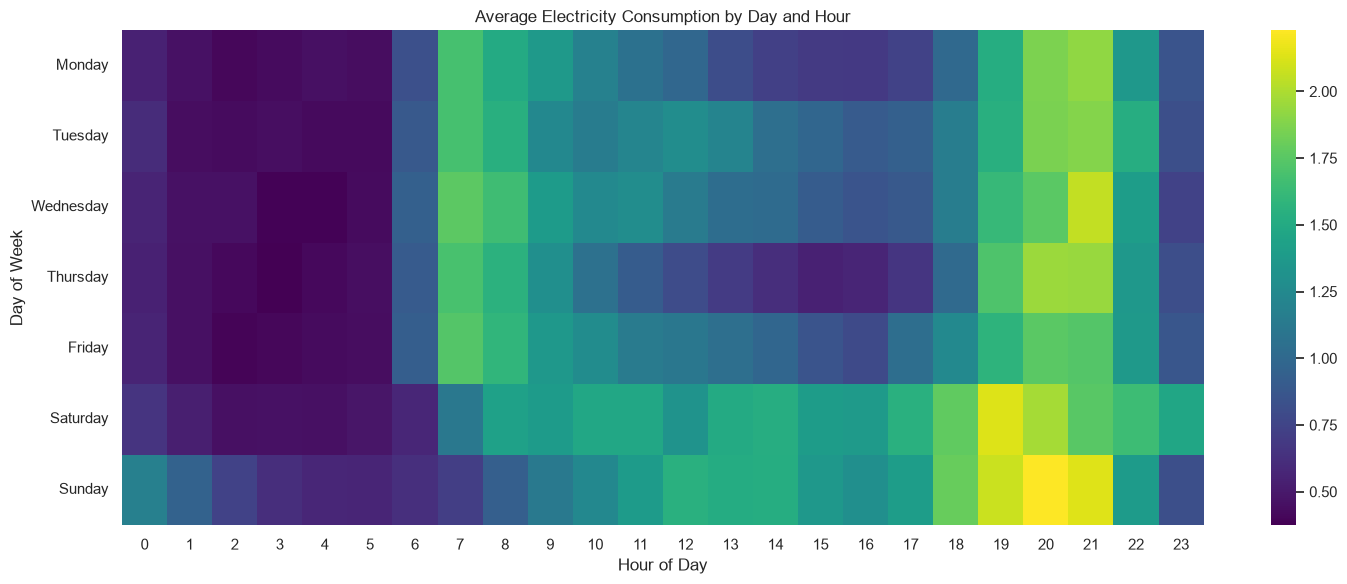

In [19]:
plt.figure(figsize=(15, 6))

sns.heatmap(
    hour_day_pattern,
    cmap="viridis"
)

plt.title("Average Electricity Consumption by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

### Interpretation

This heatmap is one of the most important EDA outputs for the project.

Look for:

- consistent high-demand hours,
- differences between weekdays and weekends,
- morning peaks,
- evening peaks,
- unusually high-demand day/hour combinations.


## 15. Identify Peak Consumption Periods

Find the top 10 hourly observations with the highest electricity consumption.


In [20]:
top_10_consumption = (
    hourly_df[["Electricity_Consumption"]]
    .sort_values("Electricity_Consumption", ascending=False)
    .head(10)
)

top_10_consumption

,Electricity_Consumption
DateTime,
2008-11-23 18:00:00,6.560533
2009-01-16 20:00:00,6.519633
2008-02-02 19:00:00,6.496033
2007-12-23 19:00:00,6.488000
2007-02-22 21:00:00,6.363867
2007-12-28 17:00:00,6.333667
2008-11-23 20:00:00,6.310567
2007-01-21 20:00:00,6.076567
2008-01-26 19:00:00,6.013800


## 16. Identify Lowest Consumption Periods

Find the 10 hourly observations with the lowest electricity consumption.


In [21]:
bottom_10_consumption = (
    hourly_df[["Electricity_Consumption"]]
    .sort_values("Electricity_Consumption", ascending=True)
    .head(10)
)

bottom_10_consumption

,Electricity_Consumption
DateTime,
2008-08-23 21:00:00,0.124000
2008-08-24 11:00:00,0.126600
2008-08-22 16:00:00,0.126800
2008-08-16 17:00:00,0.127500
2008-08-22 04:00:00,0.127533
2008-08-27 00:00:00,0.127600
2008-08-26 09:00:00,0.129233
2008-08-14 05:00:00,0.130467
2008-08-17 20:00:00,0.130967


## 17. Peak Consumption by Hour

Find the average consumption for each hour and identify the highest-demand hours.


In [22]:
peak_hours = (
    hourly_pattern
    .sort_values(ascending=False)
    .head(10)
)

peak_hours

Hour
21    1.917081
20    1.911750
19    1.740989
7     1.481431
8     1.457027
22    1.435945
9     1.308342
18    1.304436
10    1.232095
11    1.209848
Name: Electricity_Consumption, dtype: float64

## 18. Consumption by Year

Compare average hourly electricity consumption across years.


In [23]:
year_pattern = (
    hourly_df.groupby("Year")["Electricity_Consumption"]
    .mean()
)

year_pattern

Year
2006    1.904094
2007    1.111673
2008    1.072313
2009    1.015951
Name: Electricity_Consumption, dtype: float64

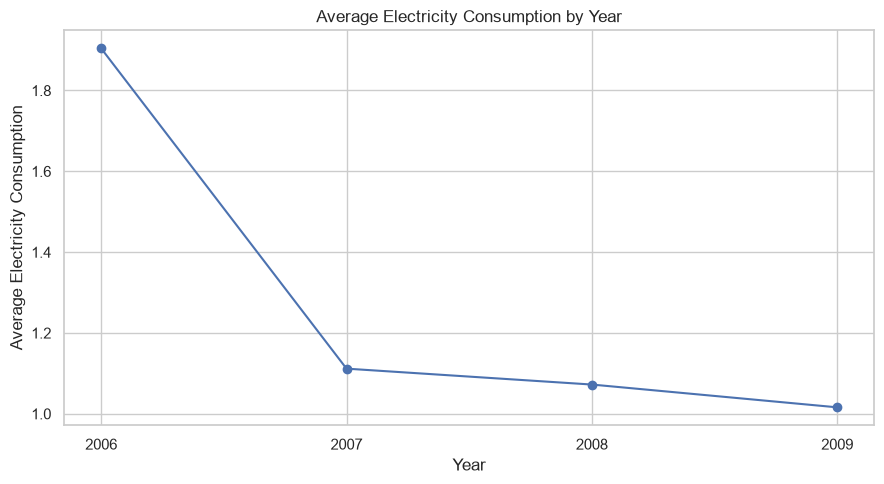

In [24]:
plt.figure(figsize=(9, 5))

plt.plot(
    year_pattern.index,
    year_pattern.values,
    marker="o"
)

plt.title("Average Electricity Consumption by Year")
plt.xlabel("Year")
plt.ylabel("Average Electricity Consumption")
plt.xticks(year_pattern.index)
plt.tight_layout()
plt.show()

## 19. Relationship Between Electrical Variables

Examine correlations among the numerical electricity measurements.

Correlation does not imply causation, but it can reveal variables that move together and may be useful for analysis or modelling.


In [25]:
numeric_columns = [
    "Electricity_Consumption",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

correlation_matrix = hourly_df[numeric_columns].corr()

correlation_matrix

,Electricity_Consumption,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Electricity_Consumption,1.000000,0.309713,-0.371989,0.999479,0.496166,0.455417,0.685825
Global_reactive_power,0.309713,1.000000,-0.151172,0.325310,0.347370,0.251503,0.109757
Voltage,-0.371989,-0.151172,1.000000,-0.383931,-0.203427,-0.166731,-0.292528
Global_intensity,0.999479,0.325310,-0.383931,1.000000,0.503183,0.462409,0.676977
Sub_metering_1,0.496166,0.347370,-0.203427,0.503183,1.000000,0.125026,0.202905
Sub_metering_2,0.455417,0.251503,-0.166731,0.462409,0.125026,1.000000,0.141114
Sub_metering_3,0.685825,0.109757,-0.292528,0.676977,0.202905,0.141114,1.000000


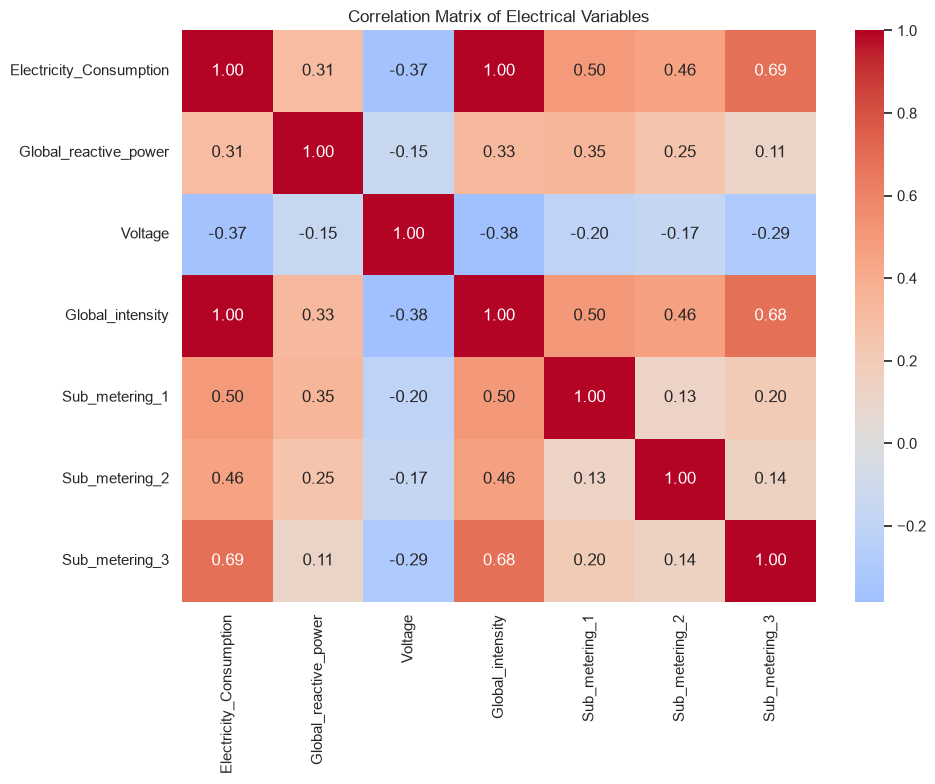

In [26]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Electrical Variables")
plt.tight_layout()
plt.show()

## 20. Consumption by Weekend Status and Hour

Compare the daily pattern for weekdays and weekends.


In [27]:
weekend_hour_pattern = (
    hourly_df.groupby(["IsWeekend", "Hour"])["Electricity_Consumption"]
    .mean()
    .unstack(level=0)
)

weekend_hour_pattern.columns = ["Weekday", "Weekend"]

weekend_hour_pattern.head()

,Weekday,Weekend
Hour,,
0,0.561060,0.915109
1,0.450805,0.742472
2,0.420627,0.592760
3,0.405970,0.537117
4,0.419874,0.512922


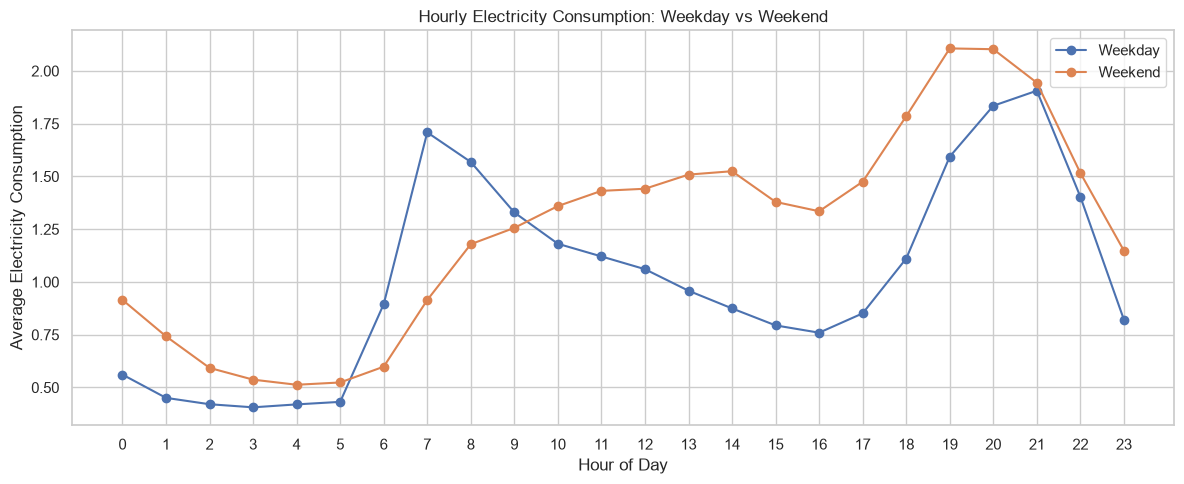

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekend_hour_pattern.index,
    weekend_hour_pattern["Weekday"],
    marker="o",
    label="Weekday"
)

plt.plot(
    weekend_hour_pattern.index,
    weekend_hour_pattern["Weekend"],
    marker="o",
    label="Weekend"
)

plt.title("Hourly Electricity Consumption: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Electricity Consumption")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

## 21. Rolling Average

A rolling average smooths short-term fluctuations and helps reveal the underlying trend.

Here we calculate a 24-hour rolling average, representing approximately one day of hourly observations.


In [29]:
hourly_df["Rolling_24h"] = (
    hourly_df["Electricity_Consumption"]
    .rolling(window=24)
    .mean()
)

hourly_df[["Electricity_Consumption", "Rolling_24h"]].head(30)

,Electricity_Consumption,Rolling_24h
DateTime,,
2006-12-16 17:00:00,4.222889,NaN
2006-12-16 18:00:00,3.632200,NaN
2006-12-16 19:00:00,3.400233,NaN
2006-12-16 20:00:00,3.268567,NaN
2006-12-16 21:00:00,3.056467,NaN
2006-12-16 22:00:00,2.200133,NaN
2006-12-16 23:00:00,2.061600,NaN
2006-12-17 00:00:00,1.882467,NaN
2006-12-17 01:00:00,3.349400,NaN


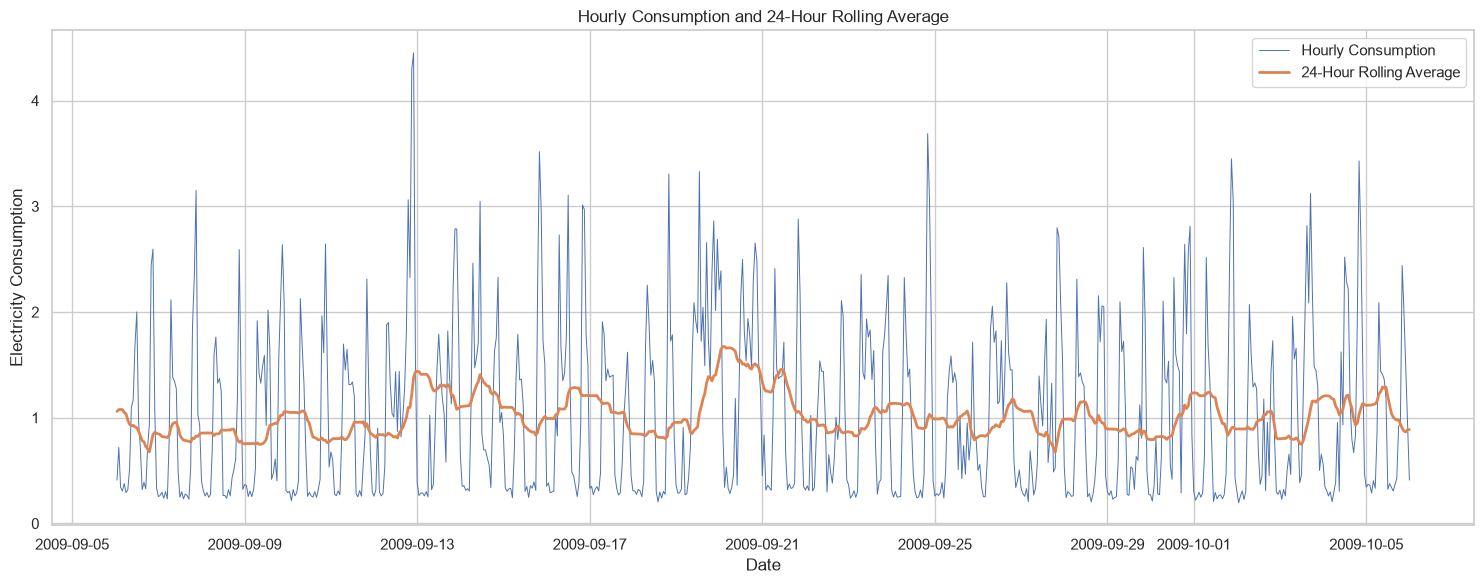

In [30]:
recent_data = hourly_df.tail(24 * 30)

plt.figure(figsize=(15, 6))

plt.plot(
    recent_data.index,
    recent_data["Electricity_Consumption"],
    linewidth=0.7,
    label="Hourly Consumption"
)

plt.plot(
    recent_data.index,
    recent_data["Rolling_24h"],
    linewidth=2,
    label="24-Hour Rolling Average"
)

plt.title("Hourly Consumption and 24-Hour Rolling Average")
plt.xlabel("Date")
plt.ylabel("Electricity Consumption")
plt.legend()
plt.tight_layout()
plt.show()

## 22. EDA Findings

After running the notebook, record the actual findings from your graphs and tables.

### Suggested questions

1. Which hours have the highest average consumption?
2. Which hours have the lowest average consumption?
3. Is weekday consumption different from weekend consumption?
4. Which day of the week has the highest average consumption?
5. Which months have higher average consumption?
6. Is there evidence of yearly variation?
7. Which observations represent the highest-demand periods?
8. Which electrical variables have the strongest correlation with electricity consumption?
9. Does the hourly heatmap show a clear daily pattern?
10. Does the rolling average reveal any long-term trend?

**Do not write conclusions before looking at your actual outputs.** Use the results generated by this notebook.


## Conclusion

This notebook provides the exploratory analysis foundation for the project.

The main patterns discovered here will be used to design features for the forecasting models.

### Next notebook

**05 - Feature Engineering**

We will create forecasting features such as:

- lagged electricity consumption,
- previous-hour consumption,
- previous-day consumption,
- previous-week consumption,
- rolling averages,
- calendar features,
- and a properly defined prediction target.

These features will prepare the dataset for machine-learning models.
